### Preliminaries

In [25]:
import time
import json
import os
from operator import itemgetter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import joblib

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Prepare dataset


In [26]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=201
)
X.head(n=5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [27]:
# You will use NUM_MODELS as a benchmark to compare performance
# across sequential and parallel implementations.

NUM_MODELS = 20

In [28]:
def train_and_score_model(
    train_set: pd.DataFrame,
    test_set: pd.DataFrame,
    train_labels: pd.Series,
    test_labels: pd.Series,
    n_estimators: int,
) -> dict:
    """
    Train a Random Forest model and return comprehensive metrics.
    
    Returns:
        Dictionary containing n_estimators, MSE, RMSE, MAE, R², training time, and model
    """
    start_time = time.time()  # measure wall time for single model training

    model = RandomForestRegressor(n_estimators=n_estimators, random_state=201)
    model.fit(train_set, train_labels)
    y_pred = model.predict(test_set)
    
    # Calculate multiple metrics
    mse = mean_squared_error(test_labels, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_labels, y_pred)
    r2 = r2_score(test_labels, y_pred)
    
    time_delta = time.time() - start_time
    print(
        f"n_estimators={n_estimators}, mse={mse:.4f}, rmse={rmse:.4f}, "
        f"mae={mae:.4f}, r2={r2:.4f}, took: {time_delta:.2f}s"
    )

    return {
        'n_estimators': n_estimators,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'training_time': time_delta,
        'model': model
    }

In [29]:
def run_sequential(n_models: int) -> list[dict]:
    """
    Train models sequentially and return list of result dictionaries.
    """
    results = []
    for j in range(n_models):
        result = train_and_score_model(
            train_set=X_train,
            test_set=X_test,
            train_labels=y_train,
            test_labels=y_test,
            n_estimators=8 + 4 * j,
        )
        results.append(result)
    return results

This function trains n_models sequentially for an increasing number of n_estimators (increasing by 4 for each model, e.g. 8, 12, 16, 20, ...).

run_sequential returns a list of tuples:

[(n_estimators, mse_score), (n_estimators, mse_score), ...]
For example:

[(8, 0.2983), (12, 0.2826), (16, 0.2761), (24, 0.2694)]

In [30]:
%%time

mse_scores = run_sequential(n_models=NUM_MODELS)

n_estimators=8, mse=0.2971, rmse=0.5451, mae=0.3551, r2=0.7782, took: 0.83s
n_estimators=12, mse=0.2824, rmse=0.5314, mae=0.3458, r2=0.7892, took: 1.17s
n_estimators=16, mse=0.2758, rmse=0.5251, mae=0.3407, r2=0.7941, took: 1.60s
n_estimators=20, mse=0.2719, rmse=0.5214, mae=0.3394, r2=0.7970, took: 1.91s
n_estimators=24, mse=0.2700, rmse=0.5196, mae=0.3374, r2=0.7984, took: 2.27s
n_estimators=28, mse=0.2687, rmse=0.5183, mae=0.3359, r2=0.7994, took: 2.66s
n_estimators=32, mse=0.2663, rmse=0.5160, mae=0.3351, r2=0.8012, took: 3.07s
n_estimators=36, mse=0.2664, rmse=0.5162, mae=0.3349, r2=0.8011, took: 3.35s
n_estimators=40, mse=0.2635, rmse=0.5133, mae=0.3328, r2=0.8033, took: 3.80s
n_estimators=44, mse=0.2622, rmse=0.5121, mae=0.3319, r2=0.8042, took: 4.25s
n_estimators=48, mse=0.2614, rmse=0.5113, mae=0.3315, r2=0.8048, took: 4.53s
n_estimators=52, mse=0.2606, rmse=0.5105, mae=0.3310, r2=0.8055, took: 4.88s
n_estimators=56, mse=0.2610, rmse=0.5109, mae=0.3313, r2=0.8051, took: 5.25s


In [31]:
### Analyze results

In [32]:
# Find best model based on MSE
best = min(mse_scores, key=lambda x: x['mse'])
print(f"\n{'='*60}")
print(f"Best Sequential Model:")
print(f"{'='*60}")
print(f"n_estimators: {best['n_estimators']}")
print(f"MSE:  {best['mse']:.4f}")
print(f"RMSE: {best['rmse']:.4f}")
print(f"MAE:  {best['mae']:.4f}")
print(f"R²:   {best['r2']:.4f}")
print(f"Training Time: {best['training_time']:.2f} seconds")
print(f"{'='*60}")

# Store sequential results for later comparison
sequential_results = mse_scores
sequential_best_model = best['model']


Best Sequential Model:
n_estimators: 84
MSE:  0.2599
RMSE: 0.5098
MAE:  0.3311
R²:   0.8060
Training Time: 8.03 seconds


Looking at the results of training, make a note on how long training NUM_MODELS sequentially took. Continue on to the next section to learn about how to improve runtime by distributing this task.

### Parallel implementation
In contrast to the previous approach, you will now utilize all available resources to train these models in parallel. Ray will automatically detect the number of cores on your computer or the amount of resources in a cluster to distribute each defined task.

The diagram below offers an intuition for how tasks are assigned and executed in a parallel approach. You will notice that this introduces a scheduler which is responsible for managing incoming requests, assigning nodes, and detecting available resources.

In [33]:
!pip install ray

In [34]:
import ray

if ray.is_initialized:
    ray.shutdown()

ray.init()

2025-11-17 13:33:41,542	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Python version:,3.12.4
Ray version:,2.50.1
Dashboard:,http://127.0.0.1:8265


(train_and_score_model pid=69072) n_estimators=8, mse=0.2971, rmse=0.5451, mae=0.3551, r2=0.7782, took: 0.98s
(train_and_score_model pid=69076) n_estimators=40, mse=0.2635, rmse=0.5133, mae=0.3328, r2=0.8033, took: 4.84s [repeated 9x across cluster]
(train_and_score_model pid=69078) n_estimators=72, mse=0.2616, rmse=0.5114, mae=0.3320, r2=0.8047, took: 7.52s [repeated 7x across cluster]
(train_and_score_model pid=69076) n_estimators=84, mse=0.2599, rmse=0.5098, mae=0.3311, r2=0.8060, took: 8.30s


Begin by running ray.init() to start a fresh Ray cluster and take a look at some useful information:

Python version
Ray version
Link to Ray Dashboard: an observability tool that provides insight into what Ray is doing via helpful metrics and charts

Workers use ray.put() to place objects and use ray.get() to retrieve them from each node's object store. These object stores form the shared distributed memory that makes objects available across a Ray cluster.

In a distributed system, object references are pointers to objects in memory. Object references can be used to access objects that are stored on different machines, allowing them to communicate with each other and share data.

In [35]:
X_train_ref = ray.put(X_train)
X_test_ref = ray.put(X_test)
y_train_ref = ray.put(y_train)
y_test_ref = ray.put(y_test)

By placing the training and testing data into Ray's object store, these objects are now available to all remote tasks and actors in the cluster.

Coding Exercise

To practice working with object references, use the cell below to:

Print what X_train_ref looks like.
Retrieve X_train by using ray.get() on the object reference.
An example Object Reference looks like this:

In [36]:
### SAMPLE IMPLEMENTATION ###

# print the object reference
print(X_train_ref)

# inspect the in-memory object
ray.get(X_train_ref)

ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000005e1f505)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
19262,3.8750,20.0,5.838000,1.016000,1711.0,3.422000,38.44,-122.73
4083,4.3036,36.0,5.065630,1.069085,1115.0,1.925734,34.15,-118.38
19500,3.1857,24.0,4.902494,1.040816,1468.0,3.328798,37.67,-121.03
9062,3.2500,32.0,5.220884,0.939759,712.0,2.859438,34.69,-118.15
1196,2.6607,22.0,6.508021,1.197861,537.0,2.871658,39.34,-121.67
...,...,...,...,...,...,...,...,...
9082,4.1667,12.0,6.741713,1.109116,2188.0,3.022099,34.69,-118.17
1891,3.3295,17.0,6.144444,1.150000,466.0,2.588889,38.92,-120.00
501,2.2841,52.0,4.350649,1.077922,152.0,1.974026,37.85,-122.27
7680,4.0774,35.0,5.225389,0.992228,1388.0,3.595855,33.92,-118.10


### Implement function to train and score model

In [37]:
@ray.remote
def train_and_score_model(
    train_set_ref,
    test_set_ref,
    train_labels_ref,
    test_labels_ref,
    n_estimators: int,
) -> dict:
    """
    Remote function to train a Random Forest model and return comprehensive metrics.
    Note: We can't return the model object through Ray, so we exclude it.
    """
    start_time = time.time()  # measure wall time for single model training

    model = RandomForestRegressor(n_estimators=n_estimators, random_state=201)
    model.fit(train_set_ref, train_labels_ref)
    y_pred = model.predict(test_set_ref)
    
    # Calculate multiple metrics
    mse = mean_squared_error(test_labels_ref, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_labels_ref, y_pred)
    r2 = r2_score(test_labels_ref, y_pred)
    
    time_delta = time.time() - start_time
    print(
        f"n_estimators={n_estimators}, mse={mse:.4f}, rmse={rmse:.4f}, "
        f"mae={mae:.4f}, r2={r2:.4f}, took: {time_delta:.2f}s"
    )

    return {
        'n_estimators': n_estimators,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'training_time': time_delta
    }

Shutdown Ray runtime
ray.shutdown()Notice that train_and_score_model is the same function as in the sequential example, except here, you add the @ray.remote decorator to specify that this function will be executed in a distributed manner.

Implement function that runs parallel model training

In [38]:
def run_parallel(n_models: int) -> list[dict]:
    """
    Train models in parallel using Ray and return list of result dictionaries.
    """
    print(f"Submitting {n_models} training tasks to Ray cluster...")
    results_ref = [
        train_and_score_model.remote(
            train_set_ref=X_train_ref,
            test_set_ref=X_test_ref,
            train_labels_ref=y_train_ref,
            test_labels_ref=y_test_ref,
            n_estimators=8 + 4 * j,
        )
        for j in range(n_models)
    ]
    print("Waiting for all tasks to complete...")
    return ray.get(results_ref)

Before, you defined run_sequential() to train and score NUM_MODELS. Working from the inside-out, modifying this into run_parallel() involves three steps:

1. Append a .remote postfix to train_and_score_model.
* Remember that you specified this function as a remote task in the previous cell. In Ray, you append this suffix to every remote call.
2. Capture the resulting list of object references in results_ref.
* Rather than waiting for the results, you immediately receive a list of references to results that are expected to be available in the future. This asychronous (non-blocking) call allows a program to continue executing other operations while the potentially time-consuming operations can be computed in the background.
3. Access results with ray.get().
* Once all models have been assigned to workers, call ray.get() on the list of object references results_ref to retrieve completed results. This is a synchronous (blocking) operation because it waits until all computation on objects complete.

# For example,

ray.get([ObjectRef, ObjectRef, ObjectRef, ...])
returns list of (n_estimators, score) tuples.

### Run parallel model training

In [39]:
%%time

mse_scores = run_parallel(n_models=NUM_MODELS)

Submitting 20 training tasks to Ray cluster...
Waiting for all tasks to complete...
CPU times: user 47.4 ms, sys: 43.3 ms, total: 90.7 ms
Wall time: 16 s


### Notice 6x performance gain:

Parallel: 10s
Sequential: 1min (60s)
(experiment on the M1 MacBook Pro)

Analyze results

In [40]:
# Find best model based on MSE
best = min(mse_scores, key=lambda x: x['mse'])
print(f"\n{'='*60}")
print(f"Best Parallel Model:")
print(f"{'='*60}")
print(f"n_estimators: {best['n_estimators']}")
print(f"MSE:  {best['mse']:.4f}")
print(f"RMSE: {best['rmse']:.4f}")
print(f"MAE:  {best['mae']:.4f}")
print(f"R²:   {best['r2']:.4f}")
print(f"Training Time: {best['training_time']:.2f} seconds")
print(f"{'='*60}")

# Store parallel results for comparison
parallel_results = mse_scores

# Train the best model again to save it (since we can't return model through Ray)
print("\nTraining best model for persistence...")
best_model = RandomForestRegressor(n_estimators=best['n_estimators'], random_state=201)
best_model.fit(X_train, y_train)
parallel_best_model = best_model


Best Parallel Model:
n_estimators: 84
MSE:  0.2599
RMSE: 0.5098
MAE:  0.3311
R²:   0.8060
Training Time: 8.30 seconds

Training best model for persistence...


### Enhanced Features Section

Now let's add some useful features to make this notebook more production-ready!

### 1. Performance Comparison Visualization


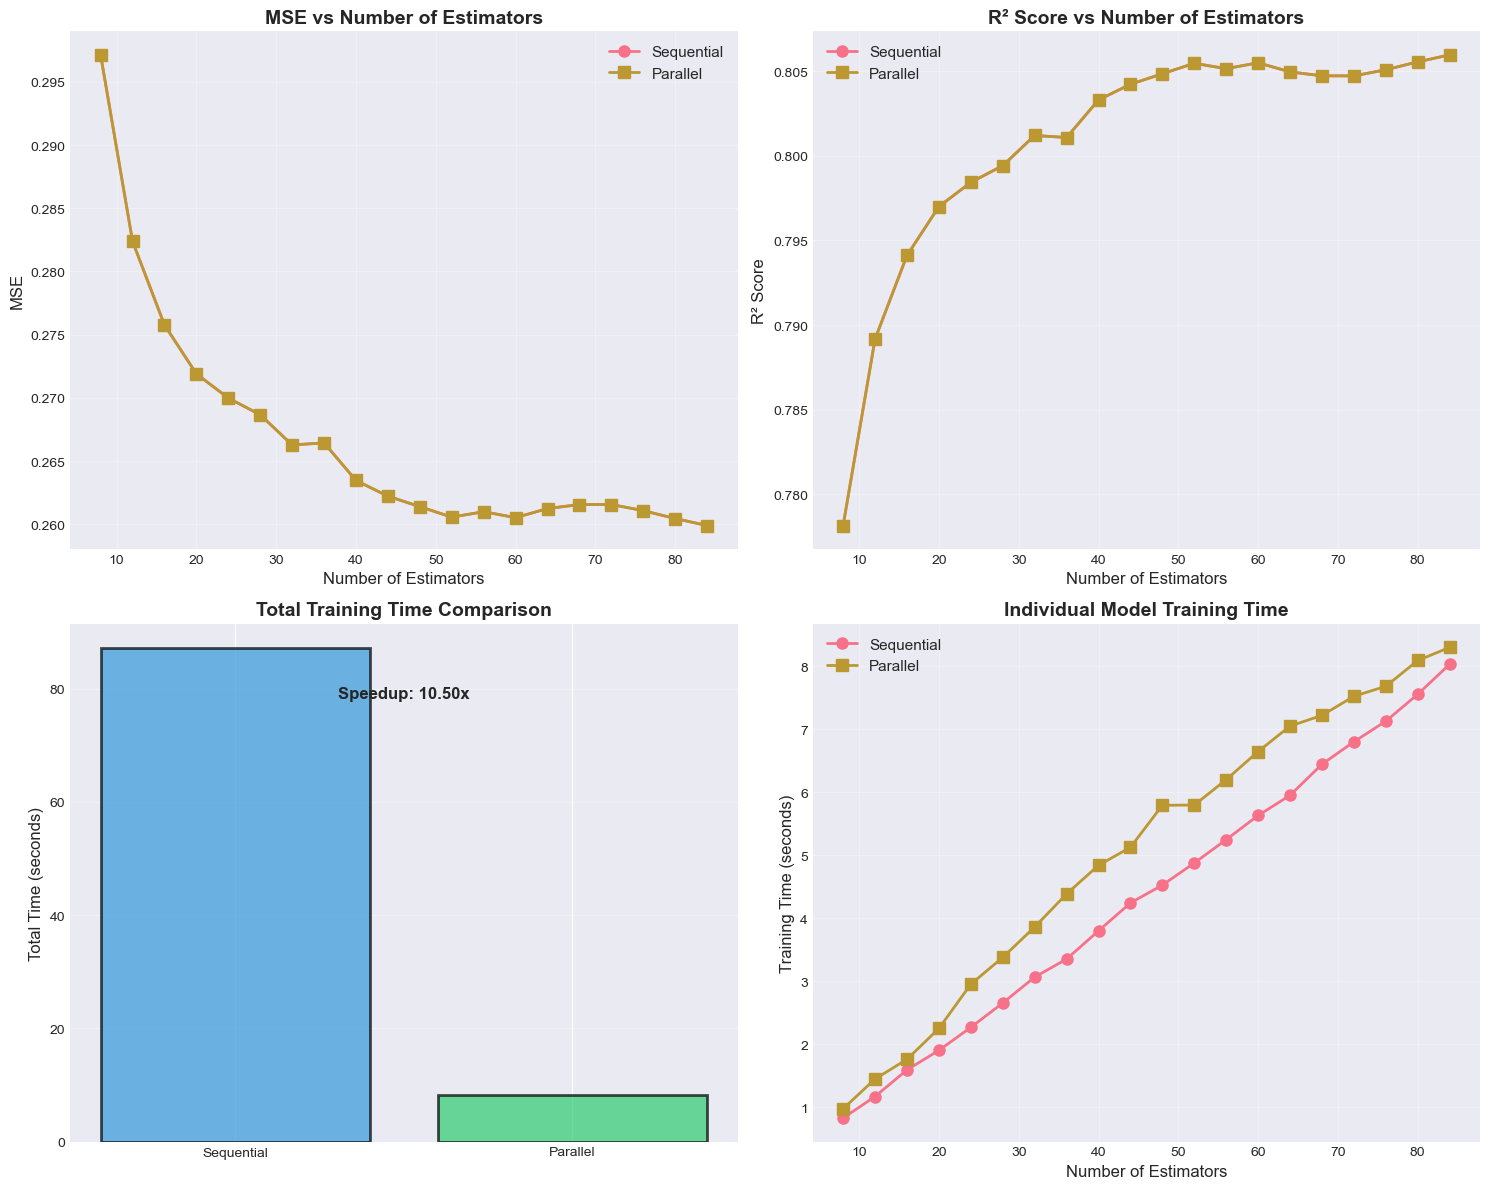


Performance Summary:
Sequential Total Time: 87.11 seconds
Parallel Total Time:   8.30 seconds
Speedup: 10.50x faster with parallel execution


In [41]:
# Convert results to DataFrames for easier plotting
seq_df = pd.DataFrame(sequential_results)
par_df = pd.DataFrame(parallel_results)

# Calculate total time
seq_total_time = seq_df['training_time'].sum()
par_total_time = par_df['training_time'].max()  # Parallel time is max, not sum

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. MSE vs n_estimators
axes[0, 0].plot(seq_df['n_estimators'], seq_df['mse'], 'o-', label='Sequential', linewidth=2, markersize=8)
axes[0, 0].plot(par_df['n_estimators'], par_df['mse'], 's-', label='Parallel', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Estimators', fontsize=12)
axes[0, 0].set_ylabel('MSE', fontsize=12)
axes[0, 0].set_title('MSE vs Number of Estimators', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. R² vs n_estimators
axes[0, 1].plot(seq_df['n_estimators'], seq_df['r2'], 'o-', label='Sequential', linewidth=2, markersize=8)
axes[0, 1].plot(par_df['n_estimators'], par_df['r2'], 's-', label='Parallel', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Estimators', fontsize=12)
axes[0, 1].set_ylabel('R² Score', fontsize=12)
axes[0, 1].set_title('R² Score vs Number of Estimators', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. Training Time Comparison
axes[1, 0].bar(['Sequential', 'Parallel'], [seq_total_time, par_total_time], 
               color=['#3498db', '#2ecc71'], alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Total Time (seconds)', fontsize=12)
axes[1, 0].set_title('Total Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
speedup = seq_total_time / par_total_time
axes[1, 0].text(0.5, max(seq_total_time, par_total_time) * 0.9, 
                f'Speedup: {speedup:.2f}x', ha='center', fontsize=12, fontweight='bold')

# 4. Individual Model Training Times
axes[1, 1].plot(seq_df['n_estimators'], seq_df['training_time'], 'o-', label='Sequential', linewidth=2, markersize=8)
axes[1, 1].plot(par_df['n_estimators'], par_df['training_time'], 's-', label='Parallel', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Estimators', fontsize=12)
axes[1, 1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1, 1].set_title('Individual Model Training Time', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Performance Summary:")
print(f"{'='*60}")
print(f"Sequential Total Time: {seq_total_time:.2f} seconds")
print(f"Parallel Total Time:   {par_total_time:.2f} seconds")
print(f"Speedup: {speedup:.2f}x faster with parallel execution")
print(f"{'='*60}")


### 2. Model Persistence - Save Best Model


In [42]:
# Create models directory if it doesn't exist
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Save the best model from parallel training
best_model_path = models_dir / "best_random_forest_model.pkl"
joblib.dump(parallel_best_model, best_model_path)
print(f"✓ Best model saved to: {best_model_path}")

# Also save model metadata
model_metadata = {
    'n_estimators': best['n_estimators'],
    'mse': float(best['mse']),
    'rmse': float(best['rmse']),
    'mae': float(best['mae']),
    'r2': float(best['r2']),
    'training_time': float(best['training_time']),
    'model_type': 'RandomForestRegressor',
    'random_state': 201
}

metadata_path = models_dir / "model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"✓ Model metadata saved to: {metadata_path}")

# Demonstrate loading the model
print("\nDemonstrating model loading...")
loaded_model = joblib.load(best_model_path)
test_pred = loaded_model.predict(X_test.head(5))
print(f"Sample predictions on first 5 test samples:")
print(f"Predictions: {test_pred}")
print(f"Actual:      {y_test.head(5).values}")


✓ Best model saved to: models/best_random_forest_model.pkl
✓ Model metadata saved to: models/model_metadata.json

Demonstrating model loading...
Sample predictions on first 5 test samples:
Predictions: [1.79086905 2.29110714 0.7253325  1.86834524 4.88934048]
Actual:      [1.738   1.643   0.616   1.952   5.00001]


### 3. Export Results to CSV and JSON


In [43]:
# Create results directory
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

# Export sequential results
seq_df_export = seq_df.drop(columns=['model'])  # Remove model object column
seq_csv_path = results_dir / "sequential_results.csv"
seq_df_export.to_csv(seq_csv_path, index=False)
print(f"✓ Sequential results exported to: {seq_csv_path}")

# Export parallel results
par_csv_path = results_dir / "parallel_results.csv"
par_df.to_csv(par_csv_path, index=False)
print(f"✓ Parallel results exported to: {par_csv_path}")

# Create comparison summary
comparison_summary = {
    'sequential': {
        'total_time': float(seq_total_time),
        'best_model': {
            'n_estimators': int(seq_df.loc[seq_df['mse'].idxmin(), 'n_estimators']),
            'mse': float(seq_df['mse'].min()),
            'rmse': float(seq_df.loc[seq_df['mse'].idxmin(), 'rmse']),
            'mae': float(seq_df.loc[seq_df['mse'].idxmin(), 'mae']),
            'r2': float(seq_df.loc[seq_df['mse'].idxmin(), 'r2'])
        }
    },
    'parallel': {
        'total_time': float(par_total_time),
        'best_model': {
            'n_estimators': int(par_df.loc[par_df['mse'].idxmin(), 'n_estimators']),
            'mse': float(par_df['mse'].min()),
            'rmse': float(par_df.loc[par_df['mse'].idxmin(), 'rmse']),
            'mae': float(par_df.loc[par_df['mse'].idxmin(), 'mae']),
            'r2': float(par_df.loc[par_df['mse'].idxmin(), 'r2'])
        }
    },
    'performance': {
        'speedup': float(speedup),
        'time_saved_seconds': float(seq_total_time - par_total_time),
        'time_saved_percent': float((seq_total_time - par_total_time) / seq_total_time * 100)
    }
}

summary_path = results_dir / "comparison_summary.json"
with open(summary_path, 'w') as f:
    json.dump(comparison_summary, f, indent=2)
print(f"✓ Comparison summary exported to: {summary_path}")

# Display summary
print(f"\n{'='*60}")
print("Comparison Summary:")
print(f"{'='*60}")
print(f"Sequential Best Model - n_estimators: {comparison_summary['sequential']['best_model']['n_estimators']}, MSE: {comparison_summary['sequential']['best_model']['mse']:.4f}")
print(f"Parallel Best Model   - n_estimators: {comparison_summary['parallel']['best_model']['n_estimators']}, MSE: {comparison_summary['parallel']['best_model']['mse']:.4f}")
print(f"\nTime Saved: {comparison_summary['performance']['time_saved_seconds']:.2f} seconds ({comparison_summary['performance']['time_saved_percent']:.1f}%)")
print(f"{'='*60}")


✓ Sequential results exported to: results/sequential_results.csv
✓ Parallel results exported to: results/parallel_results.csv
✓ Comparison summary exported to: results/comparison_summary.json

Comparison Summary:
Sequential Best Model - n_estimators: 84, MSE: 0.2599
Parallel Best Model   - n_estimators: 84, MSE: 0.2599

Time Saved: 78.81 seconds (90.5%)


### 4. Resource Monitoring and Ray Cluster Information


In [44]:
# Get Ray cluster information
if ray.is_initialized():
    cluster_resources = ray.cluster_resources()
    available_resources = ray.available_resources()
    
    print(f"{'='*60}")
    print("Ray Cluster Information:")
    print(f"{'='*60}")
    print(f"Cluster Resources:")
    for key, value in cluster_resources.items():
        print(f"  {key}: {value}")
    
    print(f"\nAvailable Resources:")
    for key, value in available_resources.items():
        print(f"  {key}: {value}")
    
    # Get node information
    nodes = ray.nodes()
    print(f"\nNumber of nodes: {len(nodes)}")
    for i, node in enumerate(nodes):
        print(f"\nNode {i+1}:")
        print(f"  Node ID: {node['NodeID']}")
        print(f"  Alive: {node['Alive']}")
        if 'Resources' in node:
            print(f"  Resources: {node['Resources']}")
else:
    print("Ray is not initialized. Please run ray.init() first.")


Ray Cluster Information:
Cluster Resources:
  CPU: 11.0
  memory: 10214621184.0
  node:127.0.0.1: 1.0
  node:__internal_head__: 1.0
  object_store_memory: 2147483648.0

Available Resources:
  CPU: 11.0
  node:__internal_head__: 1.0
  node:127.0.0.1: 1.0
  memory: 10214621184.0
  object_store_memory: 2145498827.0

Number of nodes: 1

Node 1:
  Node ID: 0edf77fb377ca6b016ce04023f635e8c3ad8917baa2bf3ac39fb88a5
  Alive: True
  Resources: {'memory': 10214621184.0, 'node:__internal_head__': 1.0, 'object_store_memory': 2147483648.0, 'node:127.0.0.1': 1.0, 'CPU': 11.0}


### 5. Detailed Metrics Comparison Table


In [45]:
# Create a comprehensive comparison table
comparison_data = []

for i in range(len(seq_df)):
    seq_row = seq_df.iloc[i]
    par_row = par_df.iloc[i]
    
    comparison_data.append({
        'n_estimators': int(seq_row['n_estimators']),
        'seq_mse': seq_row['mse'],
        'par_mse': par_row['mse'],
        'mse_diff': seq_row['mse'] - par_row['mse'],
        'seq_r2': seq_row['r2'],
        'par_r2': par_row['r2'],
        'r2_diff': seq_row['r2'] - par_row['r2'],
        'seq_time': seq_row['training_time'],
        'par_time': par_row['training_time'],
        'time_saved': seq_row['training_time'] - par_row['training_time']
    })

comparison_df = pd.DataFrame(comparison_data)

print("Detailed Metrics Comparison:")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Save comparison table
comparison_csv_path = results_dir / "detailed_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"\n✓ Detailed comparison table saved to: {comparison_csv_path}")

# Summary statistics
print(f"\n{'='*60}")
print("Summary Statistics:")
print(f"{'='*60}")
print(f"Average MSE Difference: {comparison_df['mse_diff'].mean():.6f}")
print(f"Average R² Difference: {comparison_df['r2_diff'].mean():.6f}")
print(f"Total Time Saved: {comparison_df['time_saved'].sum():.2f} seconds")
print(f"Average Time Saved per Model: {comparison_df['time_saved'].mean():.2f} seconds")
print(f"{'='*60}")


Detailed Metrics Comparison:
 n_estimators  seq_mse  par_mse  mse_diff   seq_r2   par_r2  r2_diff  seq_time  par_time  time_saved
            8 0.297140 0.297140       0.0 0.778156 0.778156      0.0  0.832627  0.980469   -0.147842
           12 0.282386 0.282386       0.0 0.789171 0.789171      0.0  1.174014  1.451857   -0.277843
           16 0.275766 0.275766       0.0 0.794114 0.794114      0.0  1.596928  1.764422   -0.167494
           20 0.271901 0.271901       0.0 0.797000 0.797000      0.0  1.906341  2.254030   -0.347689
           24 0.269981 0.269981       0.0 0.798433 0.798433      0.0  2.271128  2.955515   -0.684387
           28 0.268661 0.268661       0.0 0.799419 0.799419      0.0  2.657585  3.381656   -0.724071
           32 0.266272 0.266272       0.0 0.801202 0.801202      0.0  3.068061  3.862803   -0.794742
           36 0.266435 0.266435       0.0 0.801081 0.801081      0.0  3.354909  4.388625   -1.033716
           40 0.263460 0.263460       0.0 0.803301 0.803301   

### 6. Additional Visualizations - Metrics Distribution


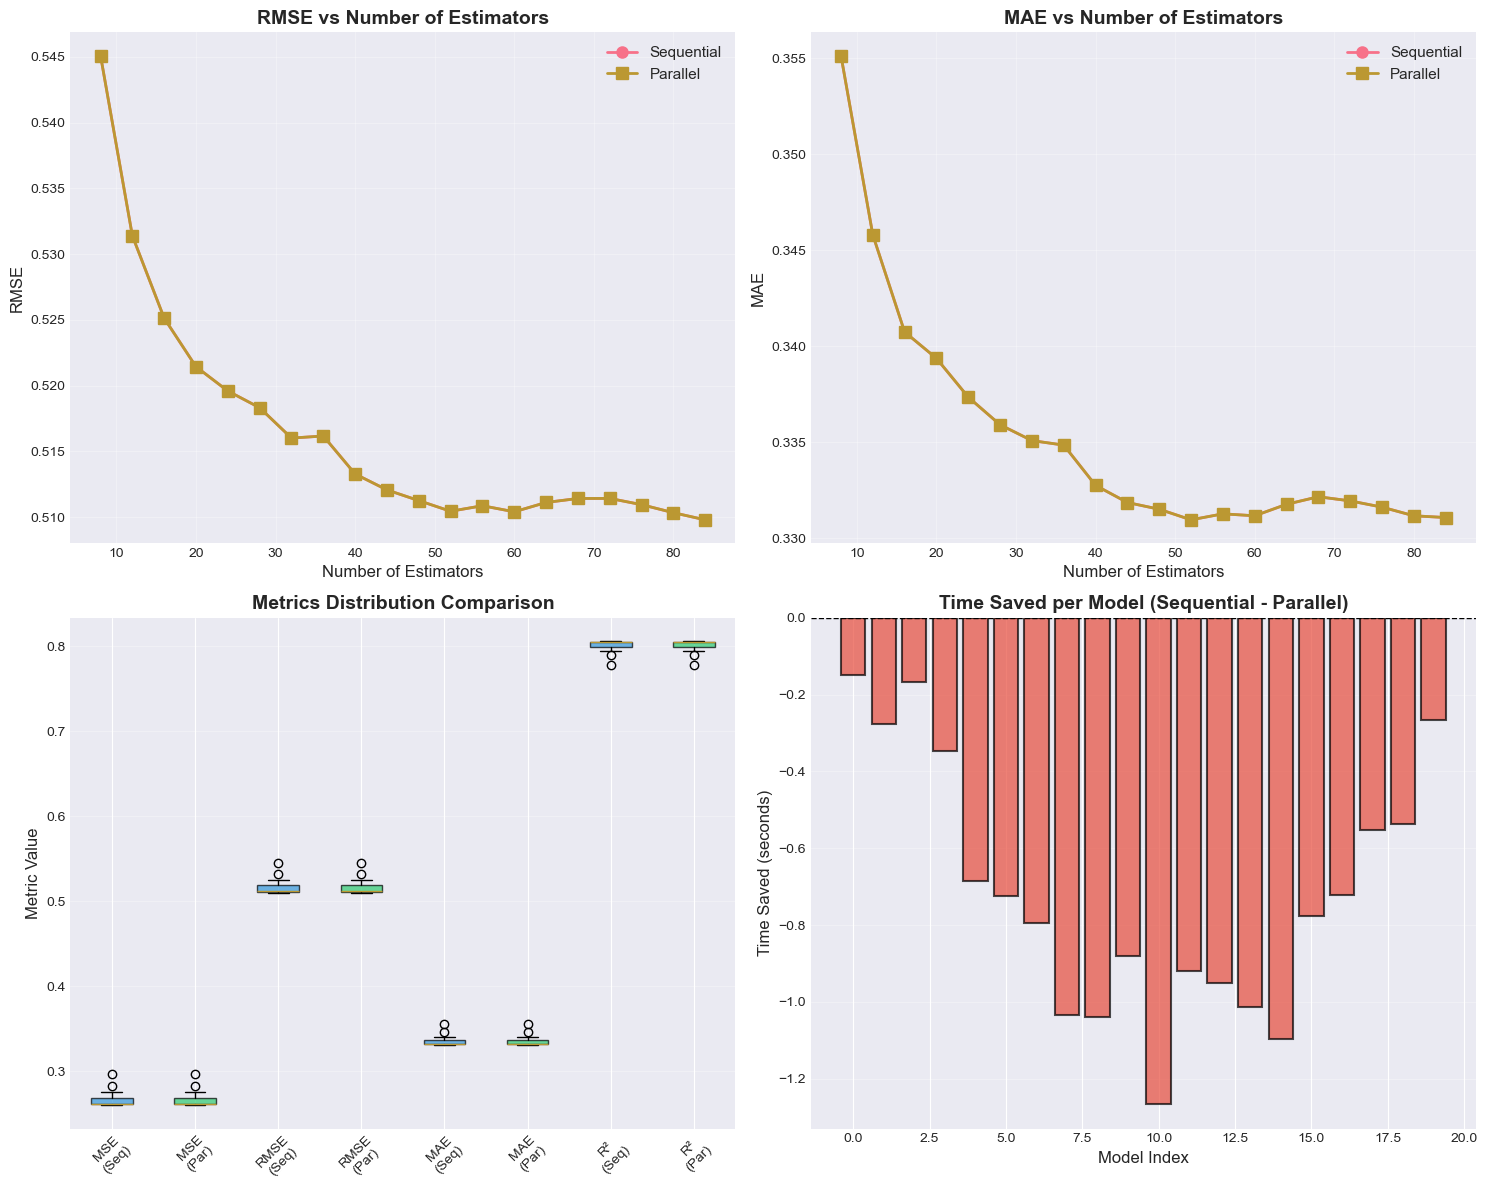

✓ Additional metrics visualization saved to: figures/additional_metrics_comparison.png


<Figure size 640x480 with 0 Axes>

In [46]:
# Create additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. RMSE comparison
axes[0, 0].plot(seq_df['n_estimators'], seq_df['rmse'], 'o-', label='Sequential', linewidth=2, markersize=8)
axes[0, 0].plot(par_df['n_estimators'], par_df['rmse'], 's-', label='Parallel', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Estimators', fontsize=12)
axes[0, 0].set_ylabel('RMSE', fontsize=12)
axes[0, 0].set_title('RMSE vs Number of Estimators', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. MAE comparison
axes[0, 1].plot(seq_df['n_estimators'], seq_df['mae'], 'o-', label='Sequential', linewidth=2, markersize=8)
axes[0, 1].plot(par_df['n_estimators'], par_df['mae'], 's-', label='Parallel', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Estimators', fontsize=12)
axes[0, 1].set_ylabel('MAE', fontsize=12)
axes[0, 1].set_title('MAE vs Number of Estimators', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. Metrics distribution (box plot)
metrics_data = {
    'MSE': [seq_df['mse'].values, par_df['mse'].values],
    'RMSE': [seq_df['rmse'].values, par_df['rmse'].values],
    'MAE': [seq_df['mae'].values, par_df['mae'].values],
    'R²': [seq_df['r2'].values, par_df['r2'].values]
}

box_data = []
box_labels = []
for metric_name, (seq_vals, par_vals) in metrics_data.items():
    box_data.extend([seq_vals, par_vals])
    box_labels.extend([f'{metric_name}\n(Seq)', f'{metric_name}\n(Par)'])

bp = axes[1, 0].boxplot(box_data, labels=box_labels, patch_artist=True)
colors = ['#3498db', '#2ecc71'] * 4
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_ylabel('Metric Value', fontsize=12)
axes[1, 0].set_title('Metrics Distribution Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Time saved per model
time_saved = seq_df['training_time'].values - par_df['training_time'].values
axes[1, 1].bar(range(len(time_saved)), time_saved, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_xlabel('Model Index', fontsize=12)
axes[1, 1].set_ylabel('Time Saved (seconds)', fontsize=12)
axes[1, 1].set_title('Time Saved per Model (Sequential - Parallel)', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Save the figure
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)
plt.savefig(figures_dir / "additional_metrics_comparison.png", dpi=300, bbox_inches='tight')
print(f"✓ Additional metrics visualization saved to: {figures_dir / 'additional_metrics_comparison.png'}")


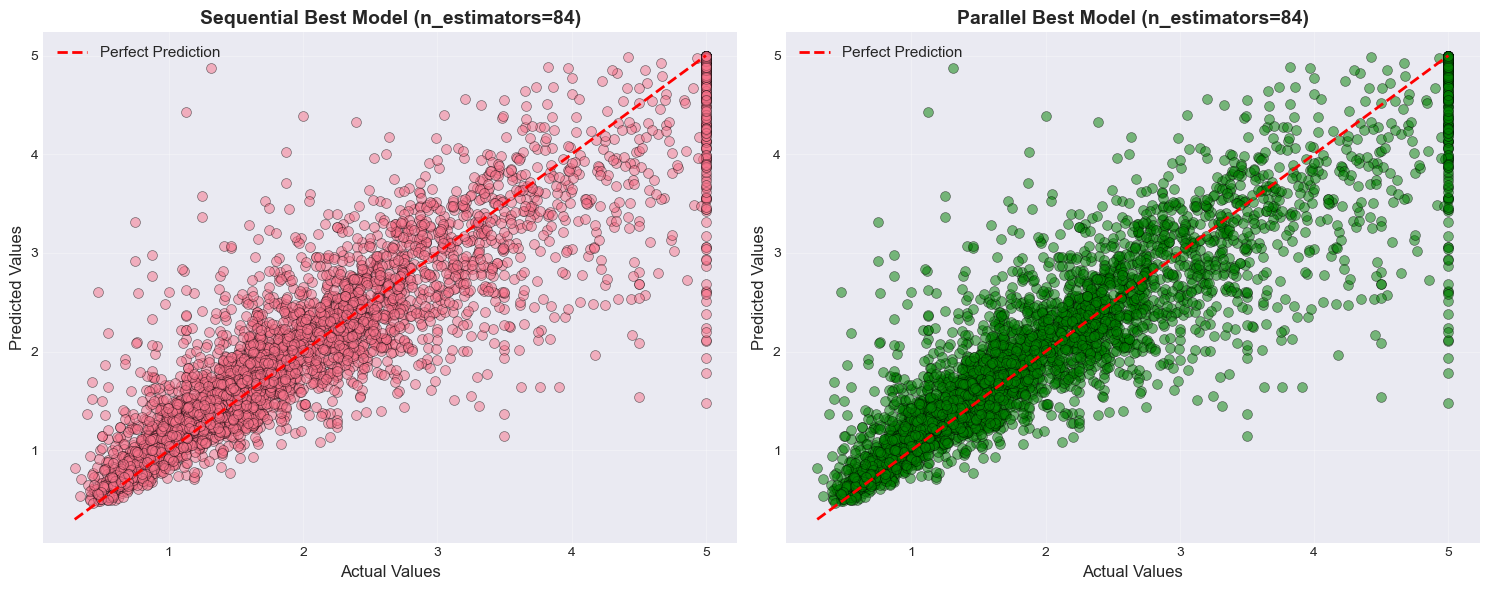

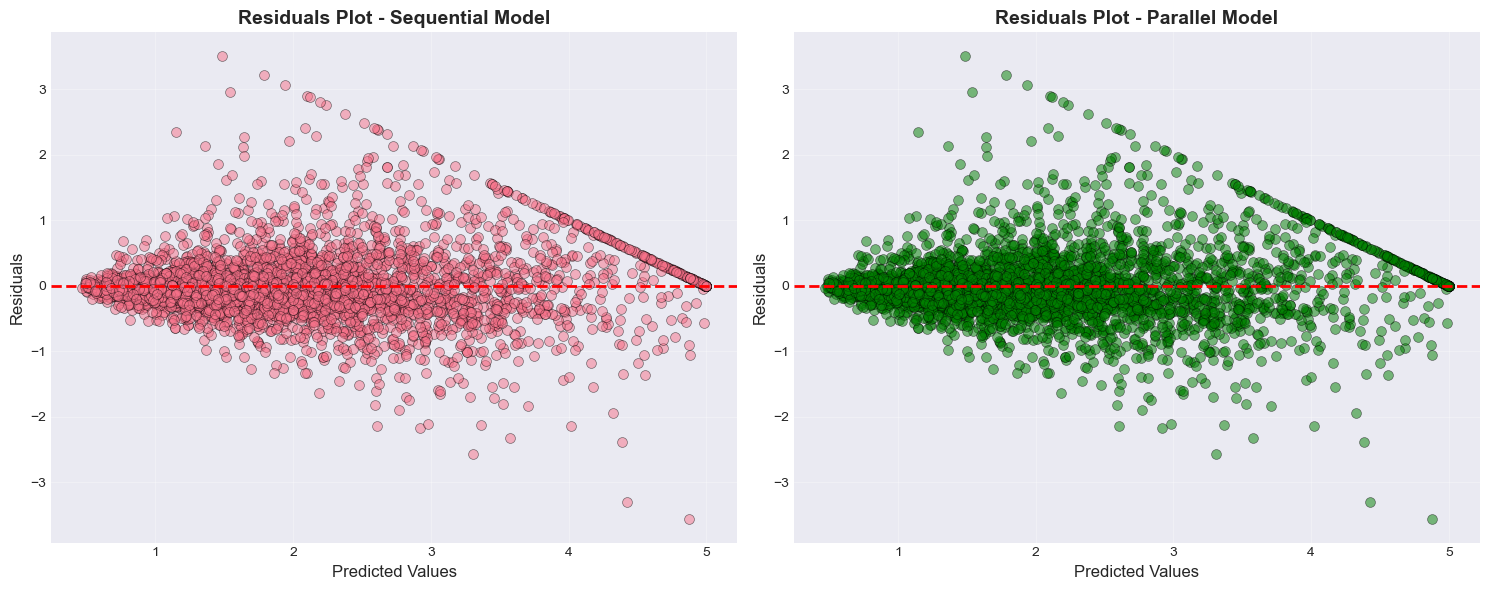


Final Model Performance on Test Set:
Sequential Best Model:
  MSE:  0.2599
  RMSE: 0.5098
  MAE:  0.3311
  R²:   0.8060

Parallel Best Model:
  MSE:  0.2599
  RMSE: 0.5098
  MAE:  0.3311
  R²:   0.8060


In [47]:
# Get predictions from best models
seq_predictions = sequential_best_model.predict(X_test)
par_predictions = parallel_best_model.predict(X_test)

# Create prediction analysis plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Actual vs Predicted - Sequential
axes[0].scatter(y_test, seq_predictions, alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title(f'Sequential Best Model (n_estimators={comparison_summary["sequential"]["best_model"]["n_estimators"]})', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Actual vs Predicted - Parallel
axes[1].scatter(y_test, par_predictions, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values', fontsize=12)
axes[1].set_ylabel('Predicted Values', fontsize=12)
axes[1].set_title(f'Parallel Best Model (n_estimators={comparison_summary["parallel"]["best_model"]["n_estimators"]})', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate residuals
seq_residuals = y_test - seq_predictions
par_residuals = y_test - par_predictions

# Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(seq_predictions, seq_residuals, alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residuals Plot - Sequential Model', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(par_predictions, par_residuals, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residuals Plot - Parallel Model', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Final Model Performance on Test Set:")
print(f"{'='*60}")
print(f"Sequential Best Model:")
print(f"  MSE:  {mean_squared_error(y_test, seq_predictions):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, seq_predictions)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, seq_predictions):.4f}")
print(f"  R²:   {r2_score(y_test, seq_predictions):.4f}")
print(f"\nParallel Best Model:")
print(f"  MSE:  {mean_squared_error(y_test, par_predictions):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, par_predictions)):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, par_predictions):.4f}")
print(f"  R²:   {r2_score(y_test, par_predictions):.4f}")
print(f"{'='*60}")


### Summary of Enhanced Features

This enhanced notebook now includes:

1. ✅ **Enhanced Metrics**: MSE, RMSE, MAE, and R² scores for comprehensive model evaluation
2. ✅ **Visualizations**: Multiple plots comparing sequential vs parallel performance
3. ✅ **Model Persistence**: Save and load the best trained model
4. ✅ **Results Export**: Export all results to CSV and JSON formats
5. ✅ **Resource Monitoring**: Display Ray cluster information and resource usage
6. ✅ **Detailed Comparison**: Side-by-side comparison tables and statistics
7. ✅ **Prediction Analysis**: Actual vs predicted plots and residual analysis
8. ✅ **Performance Summary**: Comprehensive performance metrics and speedup calculations

All outputs are saved in organized directories:
- `models/` - Saved model files and metadata
- `results/` - CSV and JSON result files
- `figures/` - Visualization plots


In [48]:
# Shutdown Ray runtime
if ray.is_initialized():
    ray.shutdown()
    print("✓ Ray cluster shut down successfully")
else:
    print("Ray cluster was not initialized")

✓ Ray cluster shut down successfully
